In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image

In [2]:
u_files = sorted(glob.glob('U/*.png'))
v_files = sorted(glob.glob('V/*.png'))

assert len(u_files) == len(v_files) , f"Mismatch in length of U and V files"

snapshots =[]
img_shape = None

for u_file, v_file in zip(u_files, v_files):
    u_mat = np.array(Image.open(u_file).convert('L'), dtype= float)
    v_mat = np.array(Image.open(v_file).convert('L'), dtype= float)

    if img_shape is None:
        img_shape = u_mat.shape

    x_k = np.concatenate((u_mat.flatten(), v_mat.flatten()))
    snapshots.append(x_k)

X = np.column_stack(snapshots)
num_pixels = img_shape[0] *img_shape[1]

print(f"Snapshot matrix X shape:{X.shape}")
    

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 1200168 and the array at index 89 has size 1201116

In [3]:
# --- CONFIGURATION ---
u_files = sorted(glob.glob('U/*.png')) 
v_files = sorted(glob.glob('V/*.png'))

assert len(u_files) == len(v_files), f"Mismatch: Found {len(u_files)} U images and {len(v_files)} V images!"
assert len(u_files) > 0, "No images found."

print(f"Found {len(u_files)} snapshots.")

snapshots = []
target_size = None # This will store the (width, height) of the first image
img_shape = None   # This stores the (rows, columns) for reshaping later

for u_file, v_file in zip(u_files, v_files):
    # Load the images as PIL objects
    img_u = Image.open(u_file).convert('L')
    img_v = Image.open(v_file).convert('L')
    
    # If this is the first image, lock in the target size
    if target_size is None:
        target_size = img_u.size # PIL uses (width, height)
        img_shape = np.array(img_u).shape # NumPy uses (height, width)
    
    # Force resize every image to perfectly match the first image
    if img_u.size != target_size:
        img_u = img_u.resize(target_size)
    if img_v.size != target_size:
        img_v = img_v.resize(target_size)
        
    # Convert to NumPy float arrays
    u_mat = np.array(img_u, dtype=float)
    v_mat = np.array(img_v, dtype=float)
        
    # Flatten and stack U on top of V
    x_k = np.concatenate((u_mat.flatten(), v_mat.flatten()))
    snapshots.append(x_k)

# Build the snapshot matrix (Columns = Time steps, Rows = Spatial points)
X = np.column_stack(snapshots)
num_pixels = img_shape[0] * img_shape[1]

print(f"Locked image shape (Height, Width): {img_shape}")
print(f"Snapshot Matrix X shape: {X.shape}")

Found 90 snapshots.
Locked image shape (Height, Width): (474, 1266)
Snapshot Matrix X shape: (1200168, 90)


In [4]:
X_mean = np.mean(X, axis = 1, keepdims = True)
X_prime = X - X_mean

##SVD

U_pod, S_pod, Vt_pod = np.linalg.svd(X_prime, full_matrices= False)

energy = (S_pod **2)/(np.sum(S_pod **2))
print("POD Complete.")
print(f"Energy in Mode 1: {energy[0]*100:.2f}%")
print(f"Energy in Mode 2: {energy[1]*100:.2f}%")

POD Complete.
Energy in Mode 1: 40.54%
Energy in Mode 2: 8.43%


In [5]:
# 1. Create time-shifted matrices
X1 = X[:, :-1]
X2 = X[:, 1:]

# 2. SVD on the first matrix (Truncated to 'r' modes to filter noise)
r = 20 # Number of dominant modes to keep (adjust as needed)
U_r, S_r_diag, Vt_r = np.linalg.svd(X1, full_matrices=False)

U_r = U_r[:, :r]
S_r = np.diag(S_r_diag[:r])
V_r = Vt_r.T[:, :r]

# 3. Compute the reduced linear operator A_tilde
# A_tilde = U_r^T * X2 * V_r * S_r^-1
S_inv = np.linalg.inv(S_r)
A_tilde = U_r.T @ X2 @ V_r @ S_inv

# 4. Eigendecomposition of A_tilde
Lambda, W = np.linalg.eig(A_tilde)

# 5. Compute exact DMD spatial modes (Phi)
# Phi = X2 * V_r * S_r^-1 * W
Phi = X2 @ V_r @ S_inv @ W

print("DMD Complete.")
print(f"Calculated {Phi.shape[1]} DMD modes.")

DMD Complete.
Calculated 20 DMD modes.


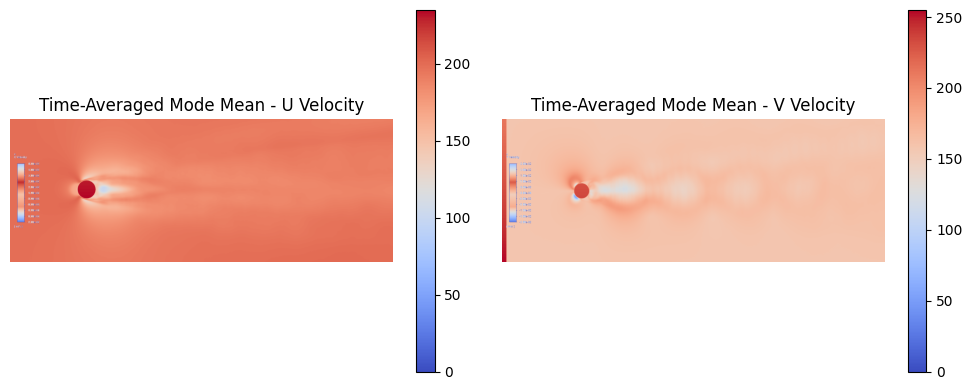

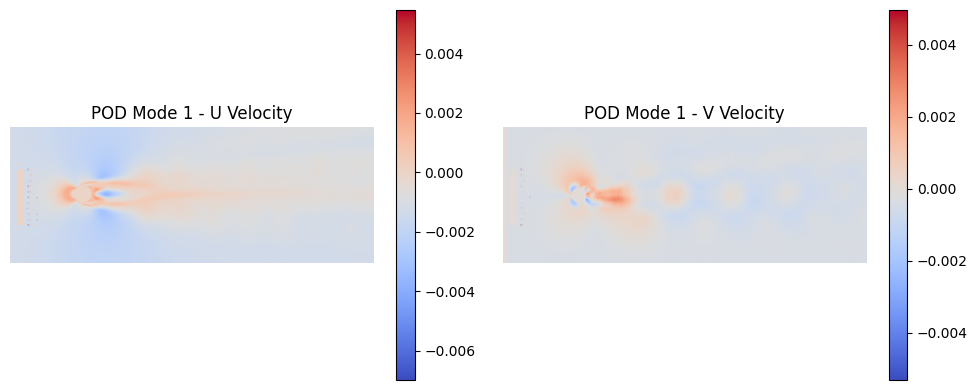

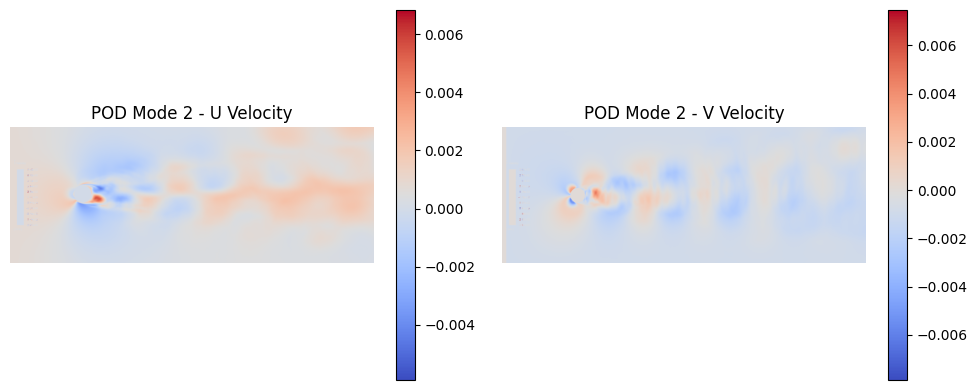

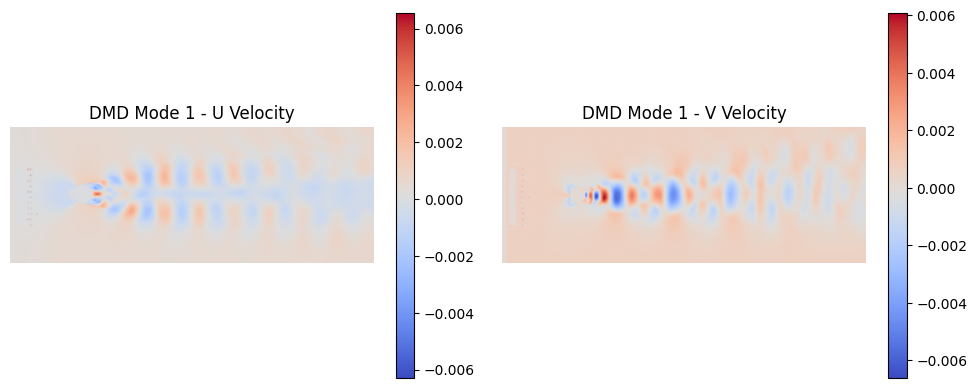

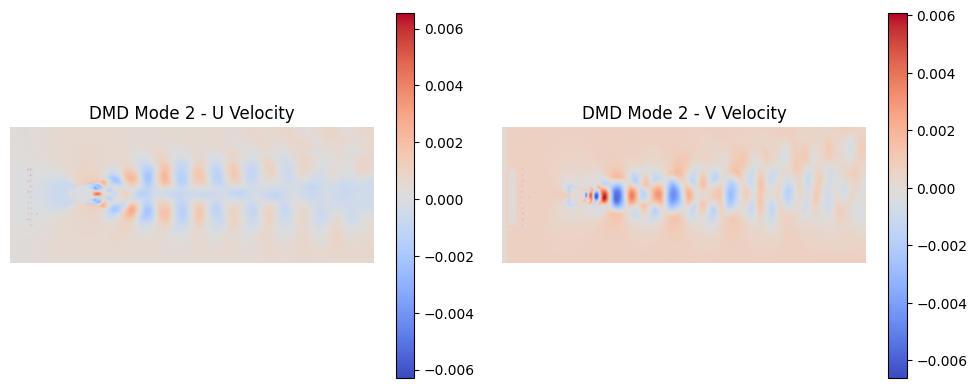

In [6]:
def plot_mode(mode_vector, mode_number, algorithm_name):
    """Slices the state vector back into U and V images and plots them."""
    
    # Slice the vector in half
    u_mode_flat = mode_vector[:num_pixels]
    v_mode_flat = mode_vector[num_pixels:]
    
    # Reshape back to 2D image dimensions
    # For DMD, the modes are complex numbers, so we plot the real part
    u_mode_2d = np.real(u_mode_flat).reshape(img_shape)
    v_mode_2d = np.real(v_mode_flat).reshape(img_shape)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    # Plot U
    c1 = ax1.imshow(u_mode_2d, cmap='coolwarm')
    ax1.set_title(f'{algorithm_name} Mode {mode_number} - U Velocity')
    fig.colorbar(c1, ax=ax1)
    ax1.axis('off')
    
    # Plot V
    c2 = ax2.imshow(v_mode_2d, cmap='coolwarm')
    ax2.set_title(f'{algorithm_name} Mode {mode_number} - V Velocity')
    fig.colorbar(c2, ax=ax2)
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

# --- Plot the results ---

# Plot the Mean Flow
plot_mode(X_mean[:, 0], "Mean", "Time-Averaged")

# Plot POD Modes 1 and 2 (Index 0 and 1)
plot_mode(U_pod[:, 0], 1, "POD")
plot_mode(U_pod[:, 1], 2, "POD")

# Plot DMD Modes 1 and 2
plot_mode(Phi[:, 0], 1, "DMD")
plot_mode(Phi[:, 1], 2, "DMD")